### Imports + Chargement

In [53]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.lightgbm
import optuna
import shap

from pathlib import Path
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix, make_scorer
)

In [20]:
# Chargement des données préparées

X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (246008, 304)
X_test  : (61503, 304)
y_train : (246008,)
y_test  : (61503,)


### Configuration MLflow

In [21]:
PROJECT_ROOT = Path.cwd().parent

db_path = PROJECT_ROOT / "mlflow.db"
mlruns_path = PROJECT_ROOT / "mlruns"
mlruns_path.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{db_path.as_posix()}")

experiment_name = "Credit Scoring - Optimization"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location=mlruns_path.resolve().as_uri()
    )

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///C:/Users/ocean/Documents/Credit-Scoring/mlruns', creation_time=1777084506242, experiment_id='2', last_update_time=1777084506242, lifecycle_stage='active', name='Credit Scoring - Optimization', tags={}, workspace='default'>

### Fonctions d'évaluation

In [ ]:
def business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Coût métier :
    FN = client risqué accepté -> coût élevé.
    FP = client solvable refusé -> coût plus faible.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost


def evaluate_predictions(y_true, y_pred, y_proba):
    """
    Calcule les métriques principales du projet.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "business_cost": business_cost(y_true, y_pred)
    }

# Transformation du coût métier en scorer compatible scikit-learn
business_scorer = make_scorer(
    business_cost,
    greater_is_better=False
)

### Modèle de référence

Le LightGBM, retenu comme meilleur candidat dans le notebook précédent, est réentraîné avec ses paramètres de base.  
Il servira de point de comparaison avant optimisation.

In [29]:
# Modèle de référence : LightGBM retenu lors de la phase précédente
baseline_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Entraînement sur l'ensemble du jeu d'apprentissage
baseline_model.fit(X_train, y_train)

# Probabilités prédites de défaut sur le jeu de test
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

# Prédictions de classes avec seuil standard de 0.5
baseline_pred = baseline_model.predict(X_test)

# Calcul des métriques de performance sur le jeu de test
baseline_metrics = evaluate_predictions(
    y_test,
    baseline_pred,
    baseline_proba
)

# Affichage
baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Métrique", "Valeur"]
)

baseline_metrics_df["Valeur"] = baseline_metrics_df["Valeur"].astype(float).round(4)

baseline_metrics_df

,Métrique,Valeur
0,accuracy,0.7341
1,roc_auc,0.7804
2,precision,0.1860
3,recall,0.6796
4,f1,0.2921
5,business_cost,30671.0000


In [ ]:
# Affichage sous forme de tableau lisible
baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Métrique", "Valeur"]
)

baseline_metrics_df["Valeur"] = baseline_metrics_df["Valeur"].astype(float).round(4)

baseline_metrics_df

### Optimisation des hyperparamètres avec Optuna

Optuna est utilisé pour rechercher automatiquement une meilleure combinaison d’hyperparamètres pour LightGBM.

L’optimisation repose sur une validation croisée stratifiée à 5 folds et cherche à minimiser le coût métier.

- n_estimators (Nombre d'arbres) : Quantité totale d'itérations.
- learning_rate (Taux d'apprentissage) : Vitesse de correction.
- num_leaves (Nombre de feuilles) : Richesse des arbres.
- max_depth (Profondeur maximale) : Limite de croissance.
- min_child_samples (Données par feuille) : Seuil de robustesse (population minimum requise).

In [28]:
def objective(trial):
    """
    Fonction utilisée par Optuna pour optimiser LightGBM.

    À chaque essai, Optuna teste une nouvelle combinaison
    d'hyperparamètres afin de minimiser le coût métier.

    Le modèle est évalué par validation croisée stratifiée à 5 folds
    pour obtenir un score moyen plus robuste.

    Le score retourné correspond à la moyenne du business_cost
    inversé (greater_is_better=False), ce qui permet à Optuna
    de maximiser la performance.
    """

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=business_scorer,
        n_jobs=-1
    )

    return scores.mean()


# Lancement de l'optimisation
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_params = study.best_params
best_params

[I 2026-04-25 10:15:13,800] A new study created in memory with name: no-name-65179556-ca54-4096-9198-f9a74b5f801d
[I 2026-04-25 10:16:06,283] Trial 0 finished with value: -25387.8 and parameters: {'n_estimators': 332, 'learning_rate': 0.011887640595731554, 'num_leaves': 62, 'max_depth': 12, 'min_child_samples': 42}. Best is trial 0 with value: -25387.8.
[I 2026-04-25 10:16:36,580] Trial 1 finished with value: -25338.4 and parameters: {'n_estimators': 282, 'learning_rate': 0.022804946495580528, 'num_leaves': 46, 'max_depth': 6, 'min_child_samples': 31}. Best is trial 1 with value: -25338.4.
[I 2026-04-25 10:18:00,325] Trial 2 finished with value: -25399.8 and parameters: {'n_estimators': 697, 'learning_rate': 0.0084093558821362, 'num_leaves': 91, 'max_depth': 7, 'min_child_samples': 32}. Best is trial 1 with value: -25338.4.
[I 2026-04-25 10:18:19,735] Trial 3 finished with value: -24948.6 and parameters: {'n_estimators': 150, 'learning_rate': 0.05612745578062587, 'num_leaves': 36, 'max

{'n_estimators': 519,
 'learning_rate': 0.04678269970170177,
 'num_leaves': 21,
 'max_depth': 5,
 'min_child_samples': 67}

In [30]:
# Affichage des meilleurs paramètres sous forme de tableau
params_df = pd.DataFrame.from_dict(
    best_params,
    orient="index",
    columns=["Valeur"]
)

params_df.index.name = "Hyperparamètre"
params_df

,Valeur
Hyperparamètre,
n_estimators,519.000000
learning_rate,0.046783
num_leaves,21.000000
max_depth,5.000000
min_child_samples,67.000000


### Entraînement du modèle optimisé

Le modèle LightGBM est réentraîné avec les meilleurs hyperparamètres identifiés par Optuna.

In [31]:
# Modèle optimisé : LightGBM réentraîné avec les meilleurs hyperparamètres trouvés par Optuna
optimized_model = LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Entraînement sur l'ensemble du jeu d'apprentissage
optimized_model.fit(X_train, y_train)

# Probabilités prédites de défaut sur le jeu de test
optimized_proba = optimized_model.predict_proba(X_test)[:, 1]

# Prédictions de classes avec seuil standard de 0.5
optimized_pred = optimized_model.predict(X_test)

# Calcul des métriques de performance sur le jeu de test
optimized_metrics = evaluate_predictions(
    y_test,
    optimized_pred,
    optimized_proba
)

# Affichage
optimized_metrics_df = pd.DataFrame(
    optimized_metrics.items(),
    columns=["Métrique", "Valeur"]
)

optimized_metrics_df["Valeur"] = optimized_metrics_df["Valeur"].astype(float).round(4)

optimized_metrics_df

,Métrique,Valeur
0,accuracy,0.7353
1,roc_auc,0.7801
2,precision,0.1867
3,recall,0.6794
4,f1,0.2930
5,business_cost,30609.0000


In [35]:
# Comparaison avant/après optimisation des hyperparamètres
comparison_df = pd.DataFrame([
    {"model": "LightGBM initial (seuil 0.50)", **baseline_metrics},
    {"model": "LightGBM optimisé (seuil 0.50)", **optimized_metrics}
])

comparison_df = comparison_df.sort_values(by="business_cost", ascending=True).reset_index(drop=True)

comparison_df.round(4)

,model,accuracy,roc_auc,precision,recall,f1,business_cost
0,LightGBM optimisé (seuil 0.50),0.7353,0.7801,0.1867,0.6794,0.2930,30609
1,LightGBM initial (seuil 0.50),0.7341,0.7804,0.1860,0.6796,0.2921,30671


Le modèle optimisé est retenu car il permet de réduire légèrement le coût métier.

### Optimisation du seuil métier

Le seuil standard de classification est 0.50.  
Dans un problème de scoring crédit, ce seuil n’est pas nécessairement optimal car les faux négatifs coûtent plus cher que les faux positifs.
Une validation interne est donc créée pour chercher le seuil minimisant le coût métier.

In [36]:
# Création d'un split interne train/validation
# Le jeu de test reste réservé à l'évaluation finale
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Réentraînement du modèle optimisé sur le sous-ensemble d'apprentissage
threshold_model = LGBMClassifier(
    **best_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

threshold_model.fit(X_train_sub, y_train_sub)

# Probabilités prédites sur la validation interne
val_proba = threshold_model.predict_proba(X_val)[:, 1]

In [40]:
# Test de plusieurs seuils de décision
thresholds = np.linspace(0.01, 0.99, 99)

# Stockage du coût obtenu pour chaque seuil
costs = []

for threshold in thresholds:
    val_pred = (val_proba >= threshold).astype(int)
    costs.append(business_cost(y_val, val_pred))

# Seuil minimisant le coût métier
best_threshold = thresholds[np.argmin(costs)]

print(f"Seuil optimal : {best_threshold:.2f}")
print(f"Coût métier minimal sur validation : {min(costs):.0f}")

Seuil optimal : 0.50
Coût métier minimal sur validation : 24827


Une recherche systématique du seuil de décision a été réalisée entre 0.01 et 0.99.
Le seuil standard de 0.50 minimise déjà le coût métier sur l’échantillon de validation.
Aucun ajustement supplémentaire n’a donc été retenu.

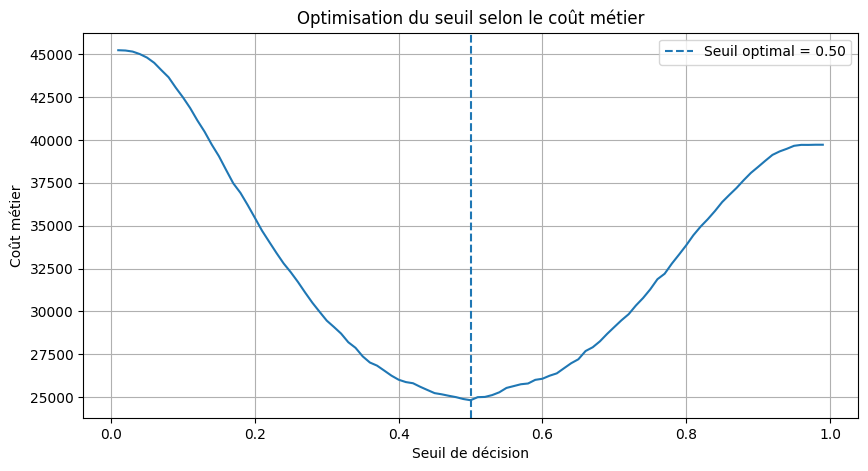

In [41]:
# Sauvegarde de la courbe d'optimisation du seuil
figures_dir = PROJECT_ROOT / "reports" / "figures" / "optimization"
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, linestyle="--", label=f"Seuil optimal = {best_threshold:.2f}")
plt.title("Optimisation du seuil selon le coût métier")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier")
plt.legend()
plt.grid(True)

threshold_plot_path = figures_dir / "threshold_optimization.png"
plt.savefig(threshold_plot_path, bbox_inches="tight")
plt.show()

In [45]:
# Si le seuil optimal diffère du seuil standard alors évaluation finale
if best_threshold != 0.50:

    final_proba = optimized_model.predict_proba(X_test)[:, 1]
    final_pred = (final_proba >= best_threshold).astype(int)

    final_metrics = evaluate_predictions(
        y_test,
        final_pred,
        final_proba
    )

    final_comparison_df = pd.DataFrame([
        {"model": "LightGBM initial (seuil 0.50)", **baseline_metrics},
        {"model": "LightGBM optimisé (seuil 0.50)", **optimized_metrics},
        {"model": f"LightGBM optimisé (seuil {best_threshold:.2f})", **final_metrics}
    ])

else:
    final_comparison_df = pd.DataFrame([
        {"model": "LightGBM initial (seuil 0.50)", **baseline_metrics},
        {"model": "LightGBM optimisé (seuil 0.50)", **optimized_metrics}
    ])

final_comparison_df.round(4)

,model,accuracy,roc_auc,precision,recall,f1,business_cost
0,LightGBM initial (seuil 0.50),0.7341,0.7804,0.1860,0.6796,0.2921,30671
1,LightGBM optimisé (seuil 0.50),0.7353,0.7801,0.1867,0.6794,0.2930,30609


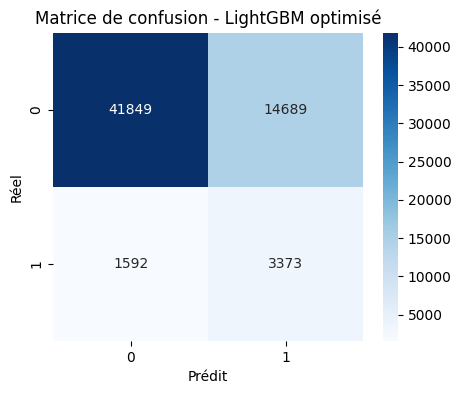

In [50]:
# Matrice de confusion du modèle LightGBM optimisé
cm = confusion_matrix(y_test, optimized_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matrice de confusion - LightGBM optimisé")
plt.xlabel("Prédit")
plt.ylabel("Réel")

cm_path = figures_dir / "confusion_matrix_optimized_lightgbm.png"
plt.savefig(cm_path, bbox_inches="tight")

plt.show()
plt.close()

### Importance des variables

L’importance des variables est analysée afin d’identifier les signaux les plus utilisés par le modèle optimisé.

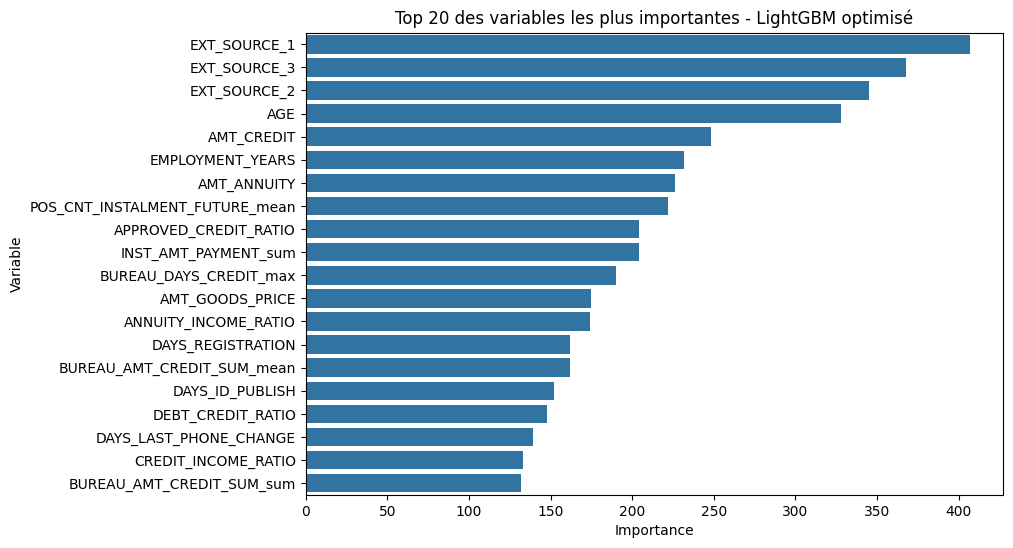

,feature,importance
25,EXT_SOURCE_1,407
27,EXT_SOURCE_3,368
26,EXT_SOURCE_2,345
164,AGE,328
2,AMT_CREDIT,248
165,EMPLOYMENT_YEARS,232
3,AMT_ANNUITY,226
137,POS_CNT_INSTALMENT_FUTURE_mean,222
174,APPROVED_CREDIT_RATIO,204
144,INST_AMT_PAYMENT_sum,204


In [51]:
# Importance des variables du modèle LightGBM optimisé
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": optimized_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
).head(20)

# Visualisation des 20 variables les plus importantes
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Top 20 des variables les plus importantes - LightGBM optimisé")
plt.xlabel("Importance")
plt.ylabel("Variable")

# Sauvegarde du graphique
feature_importance_path = figures_dir / "feature_importance_optimized_lightgbm.png"
plt.savefig(feature_importance_path, bbox_inches="tight")

plt.show()
plt.close()

# Tableau des variables importantes
feature_importance

- Les scores externes (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3) restent les variables les plus prédictives du risque client.
- Plusieurs variables créées lors du feature engineering apparaissent également dans le top des importances :
    - AGE : âge du client
    - EMPLOYMENT_YEARS : ancienneté professionnelle
    - APPROVED_CREDIT_RATIO : rapport entre montant demandé et montant accordé sur anciens dossiers
    - ANNUITY_INCOME_RATIO : mensualité du crédit rapportée au revenu
    - DEBT_CREDIT_RATIO : dette restante rapportée au total des crédits passés
    - CREDIT_INCOME_RATIO : montant du crédit demandé rapporté au revenu

Cela confirme que la création de variables métier a apporté de l'information utile au modèle.

- Les montants financiers restent également importants :

    - AMT_CREDIT : montant du crédit demandé 
    - AMT_ANNUITY : mensualité du prêt
    - AMT_GOODS_PRICE : valeur du bien financé

- L’historique bureau client joue aussi un rôle important :

    - BUREAU_DAYS_CREDIT_max : ancienneté maximale d’un crédit enregistré au bureau de crédit
    - BUREAU_AMT_CREDIT_SUM_mean / sum : montant moyen ou total des crédits passés déclarés

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


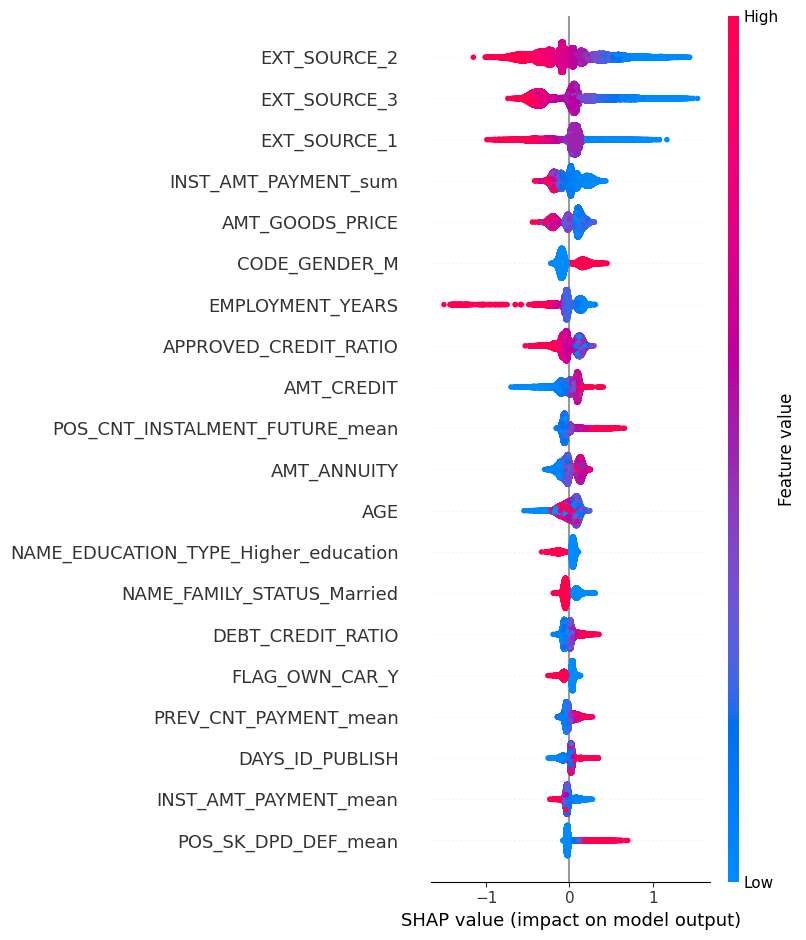

In [52]:
explainer = shap.TreeExplainer(optimized_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

- EXT_SOURCE_2, 3, 1 : Ce sont les variables les plus puissantes. Plus ces scores sont bas, plus le risque de défaut est élevé.
- CODE_GENDER_M (Homme) : Être un homme augmente légèrement la probabilité de défaut.
- POS_SK_DPD_DEF_mean : Plus il y a eu de jours de retard de paiement par le passé, plus le risque actuel est grand.
- EMPLOYMENT_YEARS : Plus la personne a d'ancienneté dans son emploi, moins elle risque de faire défaut.
- NAME_EDUCATION_TYPE_Higher_education : Le fait d'avoir un niveau d'éducation supérieure minimise le risque d'être un mauvais payeur.

### Tracking MLflow du modèle optimisé


In [54]:
# Métriques finales à logger
# Le seuil optimal est 0.50, donc les métriques finales correspondent au modèle optimisé évalué au seuil standard
final_metrics_to_log = optimized_metrics

with mlflow.start_run(run_name="FINAL_OPTIMIZED_LIGHTGBM_5FOLDS_50TRIALS"):

    # Tags
    mlflow.set_tag("stage", "optimization")
    mlflow.set_tag("evaluation_type", "train_test")
    mlflow.set_tag("model_name", "LightGBM")
    mlflow.set_tag("model_family", "boosting")
    mlflow.set_tag("imbalance_strategy", "class_weight")
    mlflow.set_tag("selection_type", "hyperparameter_optimization")
    mlflow.set_tag("optimization_method", "Optuna + threshold tuning")
    mlflow.set_tag("cv_strategy", "StratifiedKFold")
    mlflow.set_tag("cv_folds", "5")
    mlflow.set_tag("optuna_trials", "50")
    mlflow.set_tag("threshold", f"{best_threshold:.2f}")
    mlflow.set_tag(
        "description",
        "LightGBM optimisé avec Optuna, validation croisée 5 folds, 50 essais et vérification du seuil métier"
    )

    # Paramètres optimisés
    mlflow.log_params(best_params)
    mlflow.log_param("best_threshold", float(best_threshold))
    mlflow.log_param("optuna_trials", 50)
    mlflow.log_param("cv_folds", 5)

    # Métriques finales standardisées
    mlflow.log_metrics({
        "accuracy": final_metrics_to_log["accuracy"],
        "roc_auc": final_metrics_to_log["roc_auc"],
        "precision": final_metrics_to_log["precision"],
        "recall": final_metrics_to_log["recall"],
        "f1": final_metrics_to_log["f1"],
        "business_cost": final_metrics_to_log["business_cost"]
    })

    # Artefacts
    mlflow.log_artifact(str(threshold_plot_path), artifact_path="optimization_figures")
    mlflow.log_artifact(str(cm_path), artifact_path="optimization_figures")
    mlflow.log_artifact(str(feature_importance_path), artifact_path="optimization_figures")

    # Enregistrement du modèle optimisé dans le Registry
    mlflow.lightgbm.log_model(
        optimized_model,
        artifact_path="model",
        registered_model_name="Credit_Scoring_Optimized_LightGBM"
    )

2026/04/25 11:37:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 11:37:21 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Credit_Scoring_Optimized_LightGBM' already exists. Creating a new version of this model...
Created version '2' of model 'Credit_Scoring_Optimized_LightGBM'.
